<a href="https://colab.research.google.com/github/b00001/sciusproject-hyperthermia/blob/main/week1_and_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rosensweig 2002, JMMM 252:370 https://ui.adsabs.harvard.edu/abs/2002JMMM..252..370R/abstract

| Magnetic solid | Chemical formula | Ms (kA m−1) | K (kJ m−3) | c (J kg−1 K−1) | ρ (kg m−3) |
|---|---|---|---|---|---|
| Maghemite | γ-Fe2O3 | 414 | −4.6 | ∼746 | 4600 |
| Magnetite | FeO·Fe2O3 | 446 | 23–41 | 670 | 5180 |
| Cobalt ferrite | CoO·Fe2O3 | 425 | 180–200 | 700 | 4907 |
| Barium ferrite | BaO·6Fe2O3 | 380 | 300–330 | ∼650 | 5280 |


In [70]:
#USE ONLY THE UNITS SPECIFIED IN THE COMMENTS AFTER EACH VALUE IN THIS CELL

Ms_in = 446e3            # [A/m]
K_in = 32e3               # [J/m^3]
Cp_in = 670                # [J/(kg K)]
rho_in = 5180              # [kg/m^3]

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ===========INPUT===========

In [72]:
def get_val(var):
    if isinstance(var, list) and len(var) == 3:
        return np.arange(var[0], var[2] + (var[1]/2), var[1])
    return np.array(var, dtype=float)

kB_in = 1.380649e-23        # [J/K] ค่าคงที่
mu0_in = 4 * np.pi * 1e-7   # [H/m]
tau0_in = 1e-9              # [s]

H_app_in = 0.1e-3             # [Tesla]
eta_in = 0.0015             # [Pa s]
T_in = 300                   # [K] 300
f_in = 300e3              # [Hz] แก้ให้เป็น 300kHz
delta_in = 0.1e-9           # [m] ส่วนพื้นผิว 10 nm
R_in = [0.2e-9, .2e-9, 8e-9]              # [m] [0.2e-9, .2e-9, 8e-9]

kB = get_val(kB_in)
mu0 = get_val(mu0_in)
tau0 = get_val(tau0_in)
rho = get_val(rho_in)
Cp = get_val(Cp_in)
Ms = get_val(Ms_in)
K = get_val(K_in)
eta = get_val(eta_in)
T = get_val(T_in)
f = get_val(f_in)
delta = get_val(delta_in)
R = get_val(R_in)

H_app = get_val(H_app_in) / mu0                  # tesla เป็น [A/m]
omega = 2 * np.pi * f                        # [rad/s]

In [73]:
VM = (4/3) * np.pi * (R**3)
VH = VM * ((1 + (delta / R))**3)
print(f"VM: {VM}")
print(f"VH: {VH}")

VM: [3.35103216e-29 2.68082573e-28 9.04778684e-28 2.14466058e-27
 4.18879020e-27 7.23822947e-27 1.14940403e-26 1.71572847e-26
 2.44290245e-26 3.35103216e-26 4.46022381e-26 5.79058358e-26
 7.36221766e-26 9.19523226e-26 1.13097336e-25 1.37258277e-25
 1.64636210e-25 1.95432196e-25 2.29847296e-25 2.68082573e-25
 3.10339089e-25 3.56817905e-25 4.07720083e-25 4.63246686e-25
 5.23598776e-25 5.88977413e-25 6.59583661e-25 7.35618581e-25
 8.17283234e-25 9.04778684e-25 9.98305992e-25 1.09806622e-24
 1.20426043e-24 1.31708968e-24 1.43675504e-24 1.56345757e-24
 1.69739832e-24 1.83877837e-24 1.98779877e-24 2.14466058e-24]
VH: [1.13097336e-28 5.23598776e-28 1.43675504e-27 3.05362806e-27
 5.57527976e-27 9.20277208e-27 1.41371669e-26 2.05795263e-26
 2.87309120e-26 3.87923861e-26 5.09650104e-26 6.54498469e-26
 8.24479576e-26 1.02160404e-25 1.24788249e-25 1.50532554e-25
 1.79594380e-25 2.12174790e-25 2.48474846e-25 2.88695610e-25
 3.33038143e-25 3.81703507e-25 4.34892765e-25 4.92806979e-25
 5.55647209e-25

In [74]:
# Calculate xi (ξ) using the formula: μ₀MsVH₀/(k_BT)
# H_app is already in A/m
xi = (mu0 * Ms * VH * H_app) / (kB * T)

if isinstance(xi, np.ndarray) and xi.size > 1:
    print(f"Calculated xi (ξ) range: [{xi.min():.2e}, {xi.max():.2e}]")
else:
    print(f"Calculated xi (ξ): {xi:.2e}")

# Check if all xi values are less than or equal to 1
if np.all(xi <= 1):
    print("All values of xi are <= 1")
else:
    print("!!!!!!!!!!!Not all values of xi are <= 1!!!!!!!!!!!!!!!!!!!")

Calculated xi (ξ) range: [1.22e-06, 2.40e-02]
All values of xi are <= 1


# ===========TAU===========

In [75]:
# ===========TAU BROWNIAN CALCULATION===========
tau_b = (3 * eta * VH) / (kB * T)
print(f"tau_b: {tau_b}")
# ===========GAMMA CALCULATION===========
gamma = (K * VM) / (kB * T)
# ===========TAU NEEL CALCULATION===========
tau_n = (tau0/2) * np.exp(gamma)
print(f"tau_n: {tau_n}")

tau_b: [1.22874100e-10 5.68861574e-10 1.56095616e-09 3.31760070e-09
 6.05723804e-09 9.99831103e-09 1.53592625e-08 2.23585353e-08
 3.12145723e-08 4.21458163e-08 5.53707102e-08 7.11076968e-08
 8.95752189e-08 1.10991719e-07 1.35575641e-07 1.63545427e-07
 1.95119520e-07 2.30516362e-07 2.69954398e-07 3.13652068e-07
 3.61827817e-07 4.14700088e-07 4.72487322e-07 5.35407963e-07
 6.03680453e-07 6.77523237e-07 7.57154755e-07 8.42793452e-07
 9.34657770e-07 1.03296615e-06 1.13793704e-06 1.24978888e-06
 1.36874011e-06 1.49500917e-06 1.62881452e-06 1.77037458e-06
 1.91990781e-06 2.07763265e-06 2.24376753e-06 2.41853091e-06]
tau_n: [5.00129464e-10 5.01036654e-10 5.03507330e-10 5.08353663e-10
 5.16445622e-10 5.28757263e-10 5.46431611e-10 5.70870536e-10
 6.03860201e-10 6.47749030e-10 7.05705238e-10 7.82097211e-10
 8.83066848e-10 1.01741115e-09 1.19796490e-09 1.44381318e-09
 1.78390548e-09 2.26308689e-09 2.95239042e-09 3.96701770e-09
 5.49853383e-09 7.87402332e-09 1.16677777e-08 1.79182614e-08
 2.856238

In [76]:
# ===========EFFECTIVE RELAXATION TIME CALCULATION===========
tau_eff = 1 / ((1 / tau_b) + (1 / tau_n))
print(f"tau_eff: {tau_eff}")

tau_eff: [9.86398174e-11 2.66399637e-10 3.80705627e-10 4.40808831e-10
 4.75872316e-10 5.02198659e-10 5.27659245e-10 5.56657644e-10
 5.92399953e-10 6.37944313e-10 6.96824145e-10 7.73588687e-10
 8.74446222e-10 1.00816971e-09 1.18747223e-09 1.43117843e-09
 1.76774365e-09 2.24108511e-09 2.92045054e-09 3.91747021e-09
 5.41622589e-09 7.72730292e-09 1.13865929e-08 1.73380176e-08
 2.72720434e-08 4.42416469e-08 7.37184623e-08 1.25134942e-07
 2.13185375e-07 3.55889113e-07 5.64026618e-07 8.23824436e-07
 1.09561135e-06 1.34215988e-06 1.55239950e-06 1.73548733e-06
 1.90515142e-06 2.07180735e-06 2.24161509e-06 2.41778610e-06]


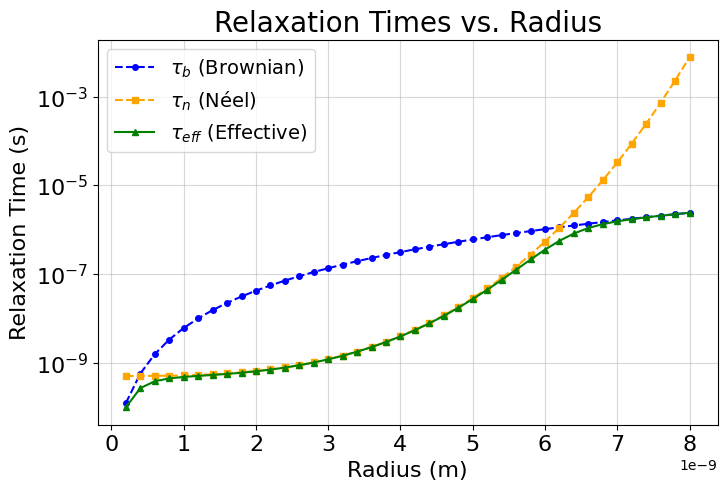

In [77]:
import matplotlib.pyplot as plt

# =========== PLOT RELAXATION TIMES VS Radius ===========

plt.figure(figsize=(8, 5))

# ใช้ตัวแปรอาเรย์ที่คำนวณไว้แล้ว (R, tau_b, tau_n, tau_eff) เพื่อพล็อตเป็นเส้นตามช่วงรัศมี
plt.plot(R, tau_b, label=r'$\tau_b$ (Brownian)', linestyle='--', marker='o', color='blue', markersize=4)
plt.plot(R, tau_n, label=r'$\tau_n$ (Néel)', linestyle='--', marker='s', color='orange', markersize=4)
plt.plot(R, tau_eff, label=r'$\tau_{eff}$ (Effective)', linestyle='-', marker='^', color='green', markersize=4)

plt.xlabel('Radius (m)', fontsize=16)
plt.ylabel('Relaxation Time (s)', fontsize=16)
plt.title('Relaxation Times vs. Radius', fontsize=20)
plt.yscale('log')
plt.legend(fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.tick_params(axis='both', labelsize=16)
plt.show()

# ===========SUSCEPTIBILITBY===========

In [78]:
import matplotlib.pyplot as plt
import numpy as np

chi0 = (mu0 * (Ms ** 2) * VM) / (3 * kB * T)
chi_prime = chi0 / (1 + (omega * tau_eff) ** 2)
chi_doubleprime = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff) ** 2)

print(f"chi0 : {chi0}")
print(f"chi_prime : {chi_prime}")
print(f"chi_doubleprime : {chi_doubleprime}")


chi0 : [6.74112508e-04 5.39290007e-03 1.82010377e-02 4.31432005e-02
 8.42640635e-02 1.45608302e-01 2.31220590e-01 3.45145604e-01
 4.91428019e-01 6.74112508e-01 8.97243749e-01 1.16486641e+00
 1.48102518e+00 1.84976472e+00 2.27512972e+00 2.76116483e+00
 3.31191475e+00 3.93142415e+00 4.62373769e+00 5.39290007e+00
 6.24295594e+00 7.17794999e+00 8.20192689e+00 9.31893131e+00
 1.05330079e+01 1.18482014e+01 1.32685565e+01 1.47981178e+01
 1.64409300e+01 1.82010377e+01 2.00824857e+01 2.20893187e+01
 2.42255812e+01 2.64953180e+01 2.89025738e+01 3.14513932e+01
 3.41458209e+01 3.69899016e+01 3.99876799e+01 4.31432005e+01]
chi_prime : [6.74112485e-04 5.39289871e-03 1.82010284e-02 4.31431707e-02
 8.42639957e-02 1.45608171e-01 2.31220362e-01 3.45145224e-01
 4.91427406e-01 6.74111534e-01 8.97242201e-01 1.16486394e+00
 1.48102116e+00 1.84975804e+00 2.27511832e+00 2.76114474e+00
 3.31187798e+00 3.93135399e+00 4.62359758e+00 5.39260602e+00
 6.24230530e+00 7.17642746e+00 8.19815025e+00 9.30898863e+00
 1.0

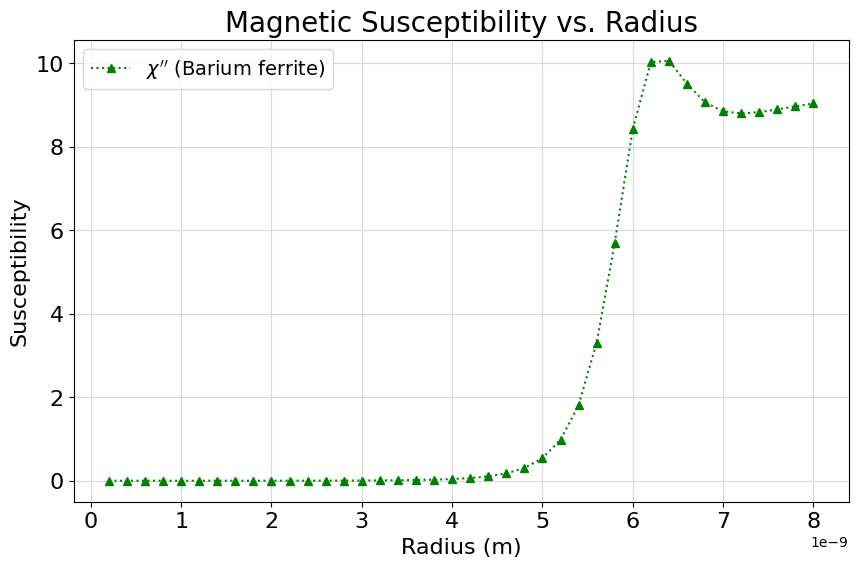

In [79]:
plt.figure(figsize=(10, 6))
# ใช้ค่าอาเรย์ที่คำนวณไว้ (R, chi_doubleprime) สำหรับวัสดุ Barium ferrite
plt.plot(R, chi_doubleprime, label=r"$\chi''$ (Barium ferrite)", marker='^', linestyle=':', color='green')

plt.xlabel('Radius (m)', fontsize=16)
plt.ylabel('Susceptibility', fontsize=16)
plt.title('Magnetic Susceptibility vs. Radius', fontsize=20)
plt.legend(loc='upper left', fontsize=14)
plt.grid(True, which="both", ls="-", color='0.85')
plt.tick_params(axis='both', labelsize=16)
plt.show()

# ===========POWER DISSIPATION===========

---



In [80]:
#POWER DISSIPATION
P = mu0 * H_app ** 2 * f * np.pi * chi_doubleprime
print(f"Power dissiption: {P}")
#Heating rate
T_s = P / (rho * Cp)
print(f"Heating rate: {T_s}")
SAR = P / rho   # [W/m³] / [kg/m³] = [W/kg]
print(f"SAR: {SAR} W/kg")

Power dissiption: [9.40041478e-04 2.03103907e-02 9.79597366e-02 2.68859095e-01
 5.66884883e-01 1.03376942e+00 1.72481299e+00 2.71614176e+00
 4.11563426e+00 6.07962671e+00 8.83883992e+00 1.27393625e+01
 1.83086682e+01 2.63639789e+01 3.81935331e+01 5.58657126e+01
 8.27667689e+01 1.24555494e+02 1.90893997e+02 2.98652931e+02
 4.77973876e+02 7.83968518e+02 1.31969039e+03 2.28173039e+03
 4.05029176e+03 7.35929584e+03 1.35661486e+04 2.47989380e+04
 4.26613575e+04 6.31537723e+04 7.51682762e+04 7.54128034e+04
 7.12685251e+04 6.79324748e+04 6.63320175e+04 6.59449801e+04
 6.61810825e+04 6.66672192e+04 6.72135354e+04 6.77380609e+04]
Heating rate: [2.70858491e-10 5.85212664e-09 2.82255911e-08 7.74676122e-08
 1.63339158e-07 2.97864756e-07 4.96978330e-07 7.82614464e-07
 1.18585670e-06 1.75175091e-06 2.54677575e-06 3.67065134e-06
 5.27536110e-06 7.59637496e-06 1.10048790e-05 1.60968457e-05
 2.38479712e-05 3.58887494e-05 5.50031685e-05 8.60522477e-05
 1.37720820e-04 2.25888468e-04 3.80248485e-04 6.5744

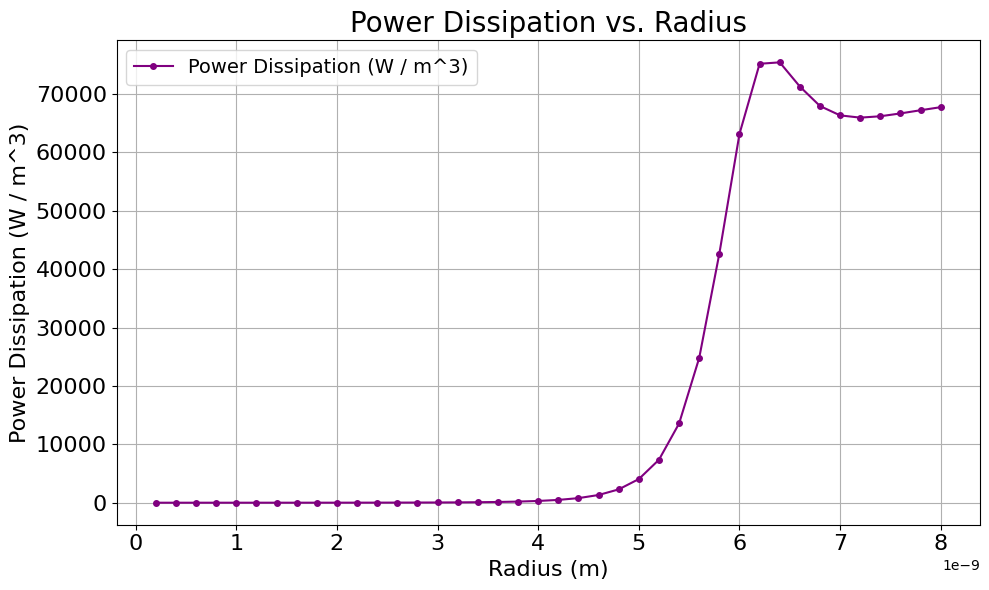

In [81]:
# Plot Power Dissipation vs Radius
plt.figure(figsize=(10, 6))
# ใช้ค่าอาเรย์ P และ R ที่คำนวณไว้แล้ว
plt.plot(R, P, marker='o', linestyle='-', color='purple', label='Power Dissipation (W / m^3)', markersize=4)
plt.ylabel('Power Dissipation (W / m^3)', fontsize=16)
plt.title('Power Dissipation vs. Radius', fontsize=20)
plt.grid(True)
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', labelsize=16)
plt.xlabel('Radius (m)', fontsize=16)
plt.tight_layout()
plt.show()

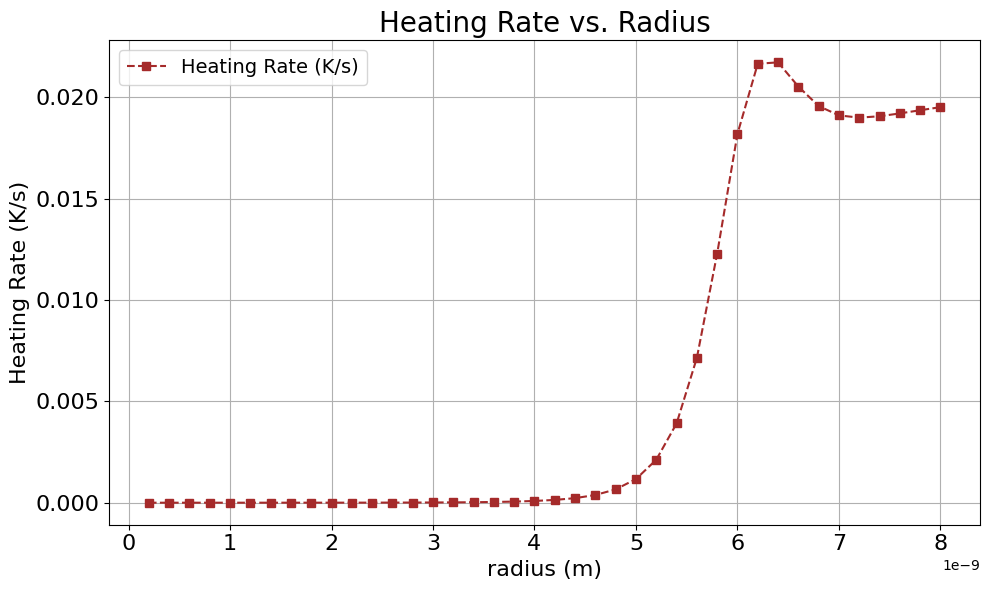

In [82]:
# Plot Heating Rate vs Radius
plt.figure(figsize=(10, 6))
# ใช้ค่าอาเรย์ T_s (heating rate) และ R ที่คำนวณไว้แล้ว
plt.plot(R, T_s, marker='s', linestyle='--', color='brown', label='Heating Rate (K/s)')
plt.ylabel('Heating Rate (K/s)', fontsize=16)
plt.title('Heating Rate vs. Radius', fontsize=20)
plt.grid(True)
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', labelsize=16)
plt.xlabel('radius (m)', fontsize=16)
plt.tight_layout()
plt.show()

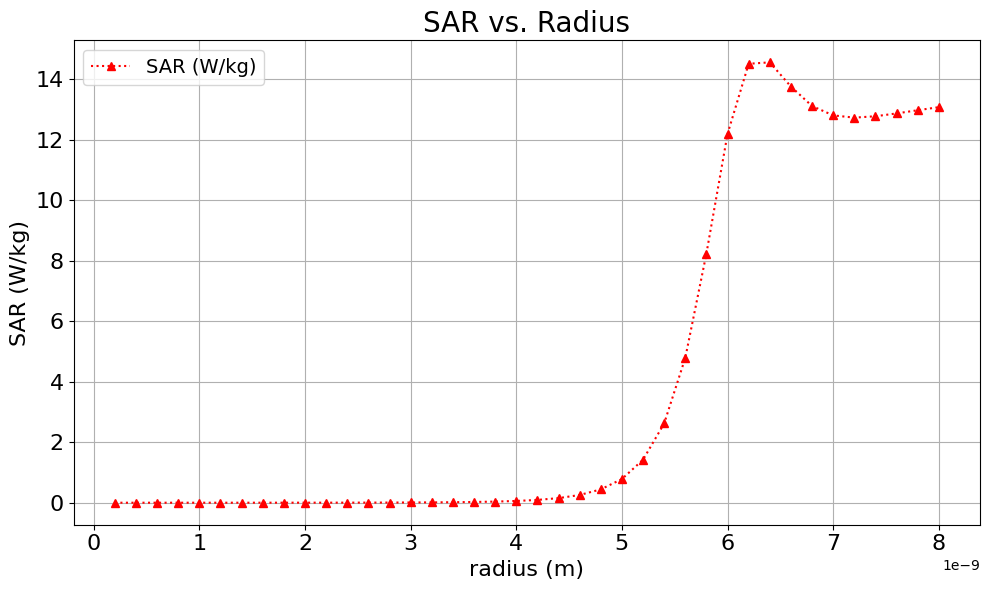

In [83]:
# Plot SAR vs Radius
plt.figure(figsize=(10, 6))
# ใช้ค่าอาเรย์ SAR และ R ที่คำนวณไว้แล้ว
plt.plot(R, SAR, marker='^', linestyle=':', color='red', label='SAR (W/kg)')
plt.xlabel('radius (m)', fontsize=16)
plt.ylabel('SAR (W/kg)', fontsize=16)
plt.title('SAR vs. Radius', fontsize=20)
plt.grid(True)
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

### Magnetic Susceptibility ($\\chi''$) vs. Radius for Different Materials

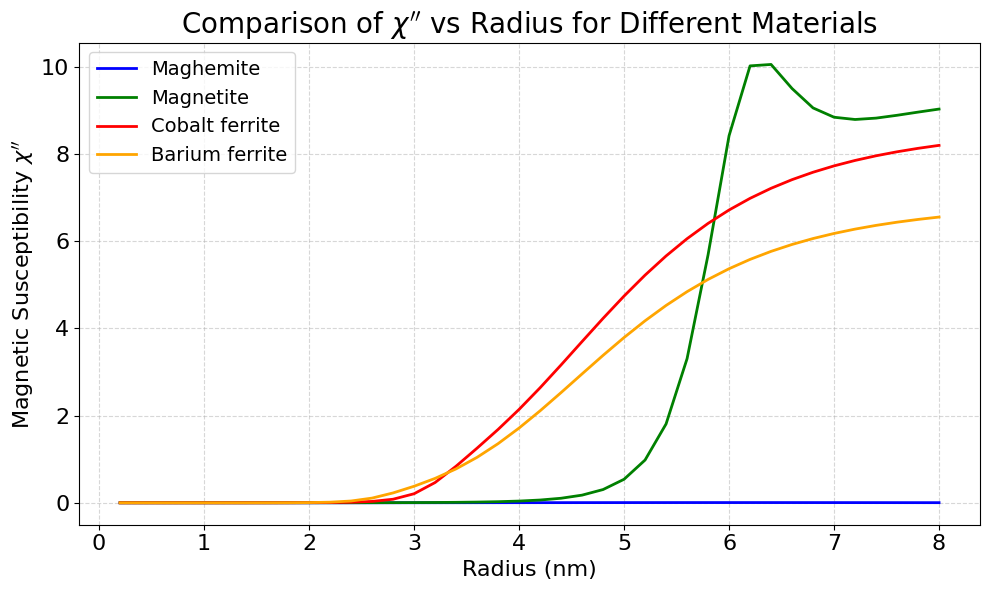

In [84]:
import matplotlib.pyplot as plt
import numpy as np

def get_val(var):
    if isinstance(var, list) and len(var) == 3:
        return np.arange(var[0], var[2] + (var[1]/2), var[1])
    return np.array(var, dtype=float)

# ---- ค่าคงที่และเงื่อนไขที่ใช้ร่วมกัน ----
mu0_c   = 4 * np.pi * 1e-7      # [H/m]
kB_c    = 1.380649e-23          # [J/K]
tau0_c  = 1e-9                  # [s]
T_c     = 300                   # [K]
f_c     = 300e3                 # [Hz]
eta_c   = 0.0015                # [Pa s]
delta_c = 0.1e-9                # [m]
H_app_c = 0.1e-3 / mu0_c        # 0.1 mT -> [A/m]
omega_c = 2 * np.pi * f_c

R_plot  = get_val([0.2e-9, 0.2e-9, 8e-9])
VM_plot = (4/3) * np.pi * (R_plot**3)
VH_plot = VM_plot * ((1 + (delta_c / R_plot))**3)
tau_b_plot = (3 * eta_c * VH_plot) / (kB_c * T_c)

materials_data = {
    'Maghemite': {'Ms': 414e3, 'K': -4.6e3, 'Cp': 746, 'rho': 4600},
    'Magnetite': {'Ms': 446e3, 'K': 32e3, 'Cp': 670, 'rho': 5180},
    'Cobalt ferrite': {'Ms': 425e3, 'K': 190e3, 'Cp': 700, 'rho': 4907},
    'Barium ferrite': {'Ms': 380e3, 'K': 315e3, 'Cp': 650, 'rho': 5280}
}

colors = {
    'Maghemite': 'blue',
    'Magnetite': 'green',
    'Cobalt ferrite': 'red',
    'Barium ferrite': 'orange'
}

chi_doubleprime_all = {}
P_all = {}
SAR_all = {}
HeatingRate_all = {}

for name, props in materials_data.items():
    current_Ms  = props['Ms']
    current_K   = props['K']
    current_rho = props['rho']
    current_Cp  = props['Cp']

    gamma_plot   = (current_K * VM_plot) / (kB_c * T_c)
    tau_n_plot   = (tau0_c/2) * np.exp(gamma_plot)
    tau_eff_plot = 1 / ((1 / tau_b_plot) + (1 / tau_n_plot))

    chi0_plot = (mu0_c * (current_Ms ** 2) * VM_plot) / (3 * kB_c * T_c)
    chi_doubleprime_plot = (chi0_plot * omega_c * tau_eff_plot) / (1 + (omega_c * tau_eff_plot) ** 2)

    # ---- power dissipation, SAR, heating rate ----
    P_plot = mu0_c * H_app_c ** 2 * f_c * np.pi * chi_doubleprime_plot

    chi_doubleprime_all[name] = chi_doubleprime_plot
    P_all[name]               = P_plot
    SAR_all[name]             = P_plot / current_rho
    HeatingRate_all[name]     = P_plot / (current_rho * current_Cp)

plt.figure(figsize=(10, 6))
for name, chi_dd in chi_doubleprime_all.items():
    plt.plot(R_plot * 1e9, chi_dd, label=name, color=colors[name], linewidth=2)

plt.xlabel('Radius (nm)', fontsize=16)
plt.ylabel(r"Magnetic Susceptibility $\chi''$", fontsize=16)
plt.title(r"Comparison of $\chi''$ vs Radius for Different Materials", fontsize=20)
plt.legend(fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

### Comparison of P, SAR, and Heating Rate for Different Materials
We will now use the previously calculated data to plot the heating characteristics across different material types.

### Individual Plots for Each Material Characteristic

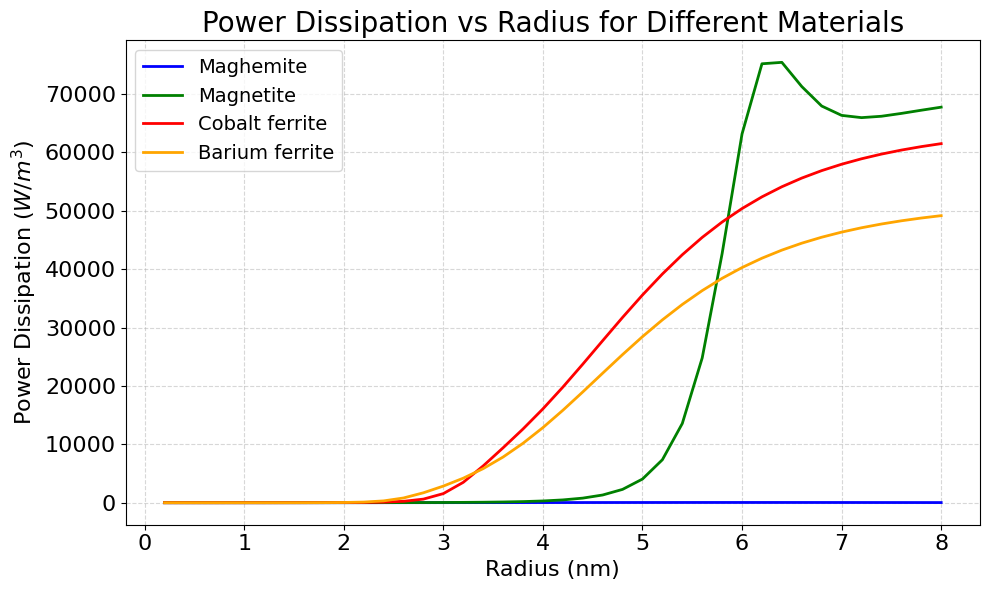

In [85]:
# 1. Individual Power Dissipation Plot
plt.figure(figsize=(10, 6))
for name in materials_data:
    plt.plot(R_plot * 1e9, P_all[name], label=name, color=colors[name], linewidth=2)
plt.xlabel('Radius (nm)', fontsize=16)
plt.ylabel('Power Dissipation ($W/m^3$)', fontsize=16)
plt.title('Power Dissipation vs Radius for Different Materials', fontsize=20)
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

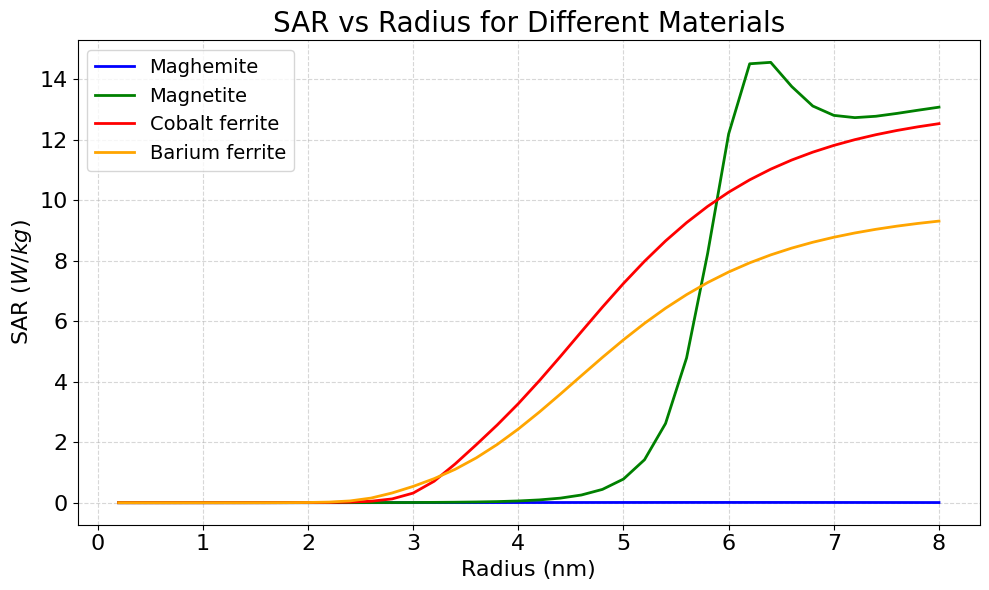

In [86]:
# 2. Individual SAR Plot
plt.figure(figsize=(10, 6))
for name in materials_data:
    plt.plot(R_plot * 1e9, SAR_all[name], label=name, color=colors[name], linewidth=2)
plt.xlabel('Radius (nm)', fontsize=16)
plt.ylabel('SAR ($W/kg$)', fontsize=16)
plt.title('SAR vs Radius for Different Materials', fontsize=20)
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

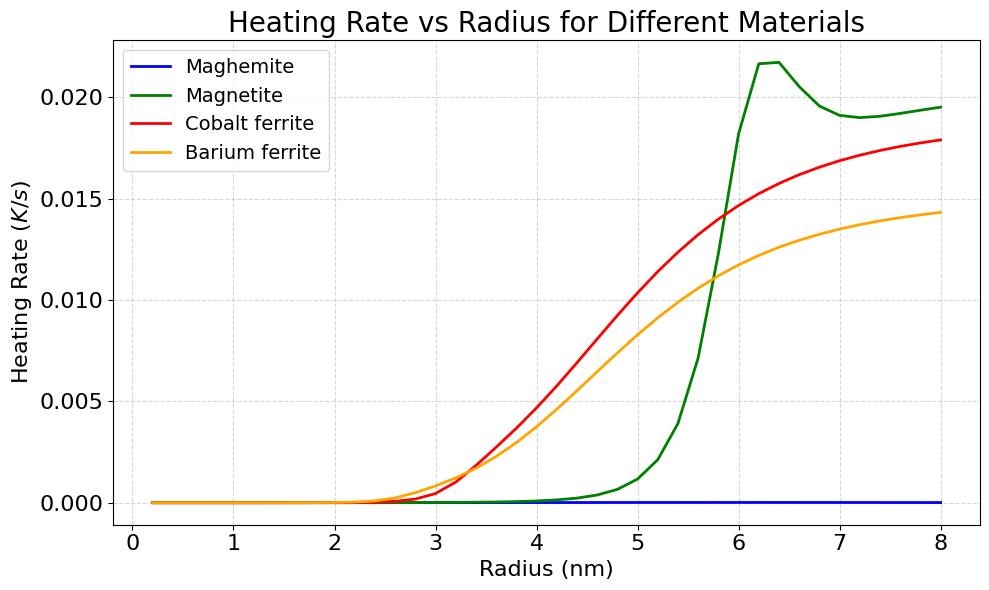

In [87]:
# 3. Individual Heating Rate Plot
plt.figure(figsize=(10, 6))
for name in materials_data:
    plt.plot(R_plot * 1e9, HeatingRate_all[name], label=name, color=colors[name], linewidth=2)
plt.xlabel('Radius (nm)', fontsize=16)
plt.ylabel('Heating Rate ($K/s$)', fontsize=16)
plt.title('Heating Rate vs Radius for Different Materials', fontsize=20)
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

==================================================================
 Nanoparticle Temperature vs Time (Magnetic Hyperthermia, LRT)
==================================================================

Validity check: LRT applies when xi = (mu0 * Ms * V_H * H0) / (kB * T) <= 1

HOW IT WORKS
------------
Fixed inputs: viscosity (eta), frequency (f), core radius (R),
              shell thickness (delta)

Field: H(t) amplitude is defined as a function of time

Procedure:
  1. Set initial temperature T_initial
  2. Loop over each time step (n_steps = t_total / dt):
       - compute H(t)
       - compute relaxation times (tau_B, tau_N, tau_eff)
       - compute chi0 and chi'' (out-of-phase susceptibility)
       - compute power dissipation P
       - compute heating rate and update temperature
       - store H(t), heating rate, temperature, and xi
  3. Stop if xi >= 1 (outside the linear response regime)


In [88]:
dt        = 1e-2      # [s]  time step
t_total   = 200       # [s]  เวลารวม
n_steps   = int(t_total / dt)
T_initial = 300.0     # [K]

# ================================================================
# ================================================================
eta   = 0.0015        # [Pa s]
f     = 300e3         # [Hz]
delta = 1e-9          # [m]
R     = 6e-9          # [m]

omega = 2 * np.pi * f
VM = (4.0 / 3.0) * np.pi * R ** 3
VH = (4.0 / 3.0) * np.pi * (R + delta) ** 3

# ================================================================
#  H_A(t) : amplitude ของสนาม [Tesla] เป็นฟังก์ชันของเวลา
#  >>> แก้สูตรตรงนี้ทีเดียว <<<
# ================================================================
H_max = 1e-3      # [T] ค่าช่วงแรก (ที่ราบสูง)
H_min = 0e-3    # [T] ค่าหลังดิ่งลง (ที่ราบต่ำ)
t0    = 40.0      # [s] จุดกึ่งกลางที่ดิ่งลง
w     = 0.8       # [s] ความชัน (เล็ก = ดิ่งชันขึ้น)

H_of_t = lambda t: H_min + (H_max - H_min) / (1 + np.exp((t - t0) / w))


In [89]:
time_array = np.zeros(n_steps + 1)
Temp_array = np.zeros(n_steps + 1)
P_array    = np.zeros(n_steps + 1)
xi_array   = np.zeros(n_steps + 1)
H_array    = np.zeros(n_steps + 1)

Temp_array[0] = T_initial
H_array[0]    = H_of_t(0.0)
xi_array[0]   = (mu0 * Ms * VH * (H_array[0] / mu0)) / (kB * T_initial)

tem_i  = T_initial
last_i = n_steps

# ================================================================
#  LOOP
# ================================================================
for i in range(1, n_steps + 1):

    t   = i * dt
    H_T = H_of_t(t)          # amplitude [Tesla] ณ เวลา t
    H_A = H_T / mu0          # Tesla -> A/m

    # ---- relaxation times ----
    gamma   = (K * VM) / (kB * tem_i)
    tau_b   = (3 * eta * VH) / (kB * tem_i)
    tau_n   = (tau0 / 2) * np.exp(gamma)
    tau_eff = 1 / ((1 / tau_b) + (1 / tau_n))

    # ---- susceptibility & power ----
    chi0 = (mu0 * Ms ** 2 * VM) / (3 * kB * tem_i)
    chi_doubleprime = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff) ** 2)
    P = mu0 * H_A ** 2 * f * np.pi * chi_doubleprime

    # ---- update temperature ----
    tem_i = tem_i + (P / (rho * Cp)) * dt

    # ---- เก็บผลลัพธ์ ----
    time_array[i] = t
    Temp_array[i] = tem_i
    P_array[i]    = P
    H_array[i]    = H_T

    # ---- ตรวจเงื่อนไข LRT (xi << 1) ----
    xi = (mu0 * Ms * VH * H_A) / (kB * tem_i)
    xi_array[i] = xi
    if xi >= 1:
        print(f"ไม่ได้: xi = {xi:.3f} >= 1 ที่ t = {t:.2f} s")
        print(f"อุณหภูมิล่าสุด = {tem_i:.4f} K")
        last_i = i
        break


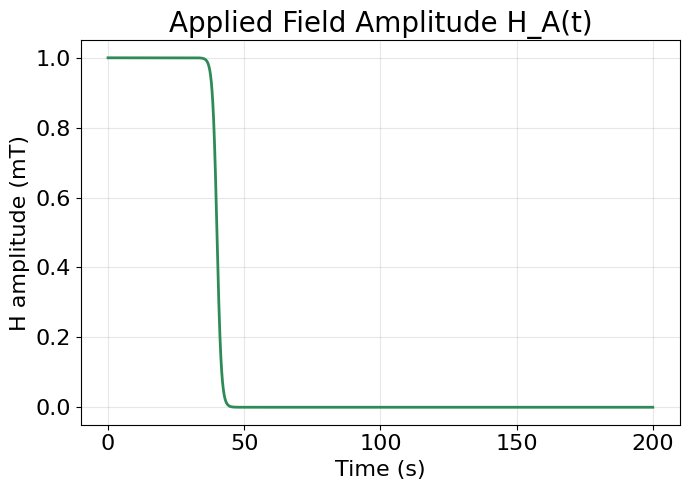

In [90]:
# ================================================================
#  PLOT
# ================================================================
sl = slice(None)
# ---- H(t) ----
plt.figure(figsize=(7, 5))
plt.plot(time_array[sl], H_array[sl] * 1e3, color='seagreen', linewidth=2)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('H amplitude (mT)', fontsize=16)
plt.title('Applied Field Amplitude H_A(t)', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

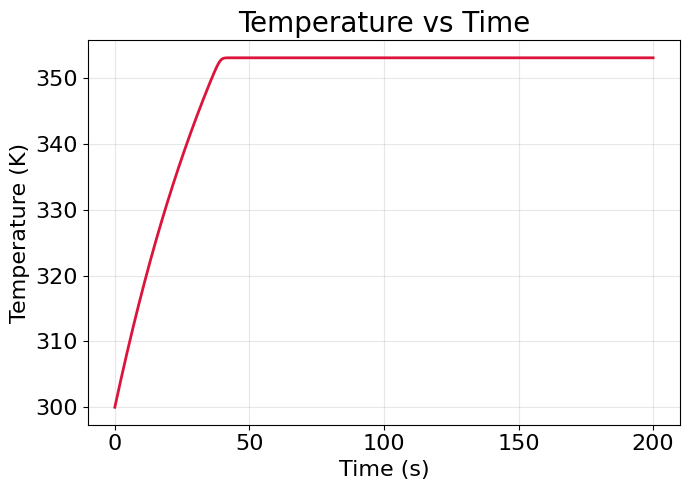

อุณหภูมิสุดท้ายที่ t = 200.00 s: 353.1358 K


In [91]:
# ---- Temperature vs Time ----
plt.figure(figsize=(7, 5))
plt.plot(time_array[sl], Temp_array[sl], color='crimson', linewidth=2)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('Temperature (K)', fontsize=16)
plt.title('Temperature vs Time', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()
print(f"อุณหภูมิสุดท้ายที่ t = {time_array[last_i]:.2f} s: {Temp_array[last_i]:.4f} K")

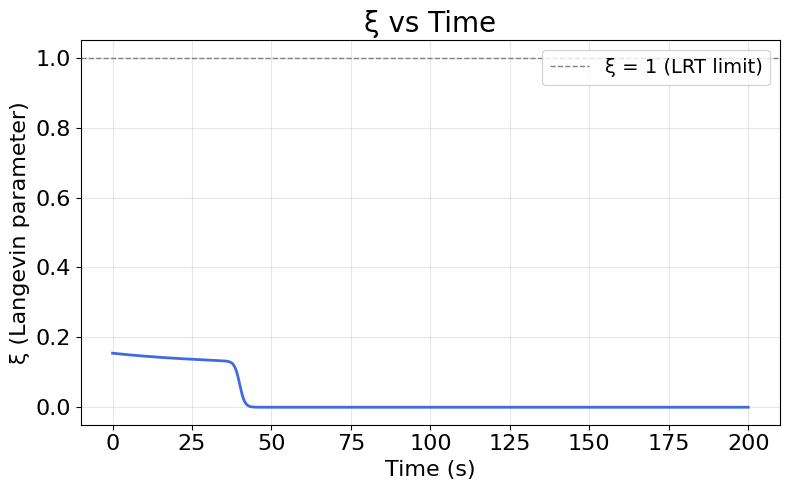

In [92]:
# ---- xi vs Time ----
plt.figure(figsize=(8, 5))
plt.plot(time_array[sl], xi_array[sl], color='royalblue', linewidth=2)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='ξ = 1 (LRT limit)')
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('ξ (Langevin parameter)', fontsize=16)
plt.title('ξ vs Time', fontsize=20)
plt.legend(loc='upper right', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()